# MSTX-Style Hedge -- Static Short + Rolling Partial-Coverage Call

Replicates the teammates' MSTX approach exactly, applied to TSLA/TSLL:

- **Static short TSLL** -- buy & hold, fixed notional, never resized.
- **Rolling long TSLA call**, 10% or 20% OTM, ~90 days (3 months) to expiry at entry.
- **Sized to cover roughly half the short's exposure** -- a partial, convex hedge
  (`HEDGE_RATIO = 0.5`), not a full delta-neutral one.
- **Rolled to a fresh 90-day contract once DTE drops to ~21 days** (three weeks) --
  calendar trigger only.

Nothing else. No daily coverage monitoring, no tiers, no breach detection, no notional
resizing, no guarantee search. Deliberately as simple as the teammates' version.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls
from options_selection import select_contract, bs_delta
from metrics import summarize

%matplotlib inline

TARGET_DTE = 90     # ~3 months, matches the MSTX approach exactly
ROLL_DTE = 21        # ~3 weeks remaining triggers a roll
MAX_DTE = 130         # a bit of slack past TARGET_DTE for contract selection
HEDGE_RATIO = 0.5    # covers roughly HALF the short's exposure -- partial, not delta-neutral
TSLL_LEVER = 2.0     # TSLL's nominal leverage vs TSLA
R_RF = 0.05
VOL_WINDOW = 21

## Load data

In [3]:
tsll_spot = load_tsll().set_index("Date")["Close"]
tsla_spot = load_tsla_underlying().set_index("Date")["Close"].reindex(tsll_spot.index).ffill()
tsla_sigma = (tsla_spot.pct_change().rolling(VOL_WINDOW).std() * (252 ** 0.5)).ffill().bfill()

tsla_calls = load_tsla_calls()
tsla_lookup = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

dates = tsll_spot.index
print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

963 trading days, 2022-08-09 -> 2026-06-10


## Simulation -- exactly the MSTX methodology, nothing added

In [4]:
def simulate_mstx_style(moneyness_bucket, notional=1.0, hedge_ratio=HEDGE_RATIO):
    """Static short TSLL + rolling TSLA call, sized to hedge_ratio x full delta-neutral
    coverage, rolled on a calendar DTE trigger only -- no re-strike trigger. Also tracks
    the REALIZED hedge ratio each day: (current option dollar delta) / (TSLL_LEVER x
    notional). Equals `hedge_ratio` exactly at the moment each contract is struck, then
    drifts as delta moves with spot/vol/time until the next roll -- same coverage-drift
    concept explored earlier this session, applied here to a static, non-reactive hedge."""
    S_incep = float(tsll_spot.loc[dates[0]])
    n_shares = notional / S_incep  # fixed forever -- static short

    short_pnl = 0.0
    option_pnl = 0.0
    position = None
    S_prev = S_incep
    n_rolls = 0

    equity = pd.Series(index=dates, dtype=float)
    hr_track = pd.Series(index=dates, dtype=float)

    def mtm(pos, date):
        if date > pos["expiry"]:
            return max(float(tsla_spot.loc[date]) - pos["strike"], 0.0)
        px = tsla_lookup.get((pos["raw_id"], date))
        return float(px) if px is not None and pd.notna(px) else pos["price"]

    def open_position(d):
        row = select_contract(tsla_calls, tsla_spot, d, moneyness_bucket, TARGET_DTE, max_dte=MAX_DTE)
        if row is None:
            return None
        S_tsla = float(tsla_spot.loc[d])
        sigma = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
        T = max((row["expiry"] - d).days / 365.25, 1 / 365)
        delta = bs_delta(S_tsla, float(row["strike"]), T, R_RF, sigma)
        n = hedge_ratio * TSLL_LEVER * notional / (max(delta, 0.01) * 100 * S_tsla)
        return {"raw_id": row["raw_id"], "strike": float(row["strike"]), "expiry": row["expiry"],
                "n": n, "price": float(row["px_last"])}

    for d in dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        held_dte = (position["expiry"] - d).days if position is not None else -1
        need_roll = position is None or held_dte < ROLL_DTE

        if need_roll:
            new_pos = open_position(d)
            if new_pos is not None:
                position = new_pos
                n_rolls += 1
            # if no contract available, hold whatever was there -- no fallback logic

        equity.loc[d] = notional + short_pnl + option_pnl

        if position is not None:
            S_tsla_now = float(tsla_spot.loc[d])
            sigma_now = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
            T_now = max((position["expiry"] - d).days / 365.25, 1 / 365)
            delta_now = bs_delta(S_tsla_now, position["strike"], T_now, R_RF, sigma_now)
            hr_track.loc[d] = (position["n"] * delta_now * 100 * S_tsla_now) / (TSLL_LEVER * notional)
        else:
            hr_track.loc[d] = float("nan")

    return equity, n_rolls, hr_track


## Run: 10% OTM and 20% OTM

In [5]:
results = {}
for bucket in ["10% OTM", "20% OTM"]:
    eq, n_rolls, hr_track = simulate_mstx_style(bucket)
    results[bucket] = (eq, n_rolls)
    print(f"{bucket}: {n_rolls} rolls, final equity = {eq.iloc[-1]:.4f}")

# static short alone, for comparison (same as S1 in the MSTX deck)
r_tsll = tsll_spot.pct_change().dropna()
cum = (1 + r_tsll).cumprod()
equity_static_short = 2.0 - cum  # short $1 TSLL, buy & hold -- same convention as engine.buy_and_hold_equity
equity_static_short = equity_static_short.reindex(dates).ffill().fillna(1.0)

10% OTM: 23 rolls, final equity = 3.9642
20% OTM: 28 rolls, final equity = 4.3917


## Risk metrics -- matches the MSTX deck's table (Equity Value, Sharpe, Max DD)

In [6]:
rows = []
rows.append(summarize(equity_static_short, equity_static_short.pct_change().dropna(), "S1 Static Short (TSLL)"))
for bucket, (eq, n_rolls) in results.items():
    row = summarize(eq, eq.pct_change().dropna(), f"Short TSLL + {bucket} TSLA Call (hr=0.5)")
    row["Rolls"] = n_rolls
    rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df

,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar,Rolls
0,S1 Static Short (TSLL),0.111697,0.709085,0.471940,-0.810748,0.137770,NaN
1,Short TSLL + 10% OTM TSLA Call (hr=0.5),0.431998,0.220334,1.745915,-0.115942,3.725975,23.0
2,Short TSLL + 20% OTM TSLA Call (hr=0.5),0.470746,0.283984,1.503950,-0.252502,1.864324,28.0


## Plot: equity + drawdown

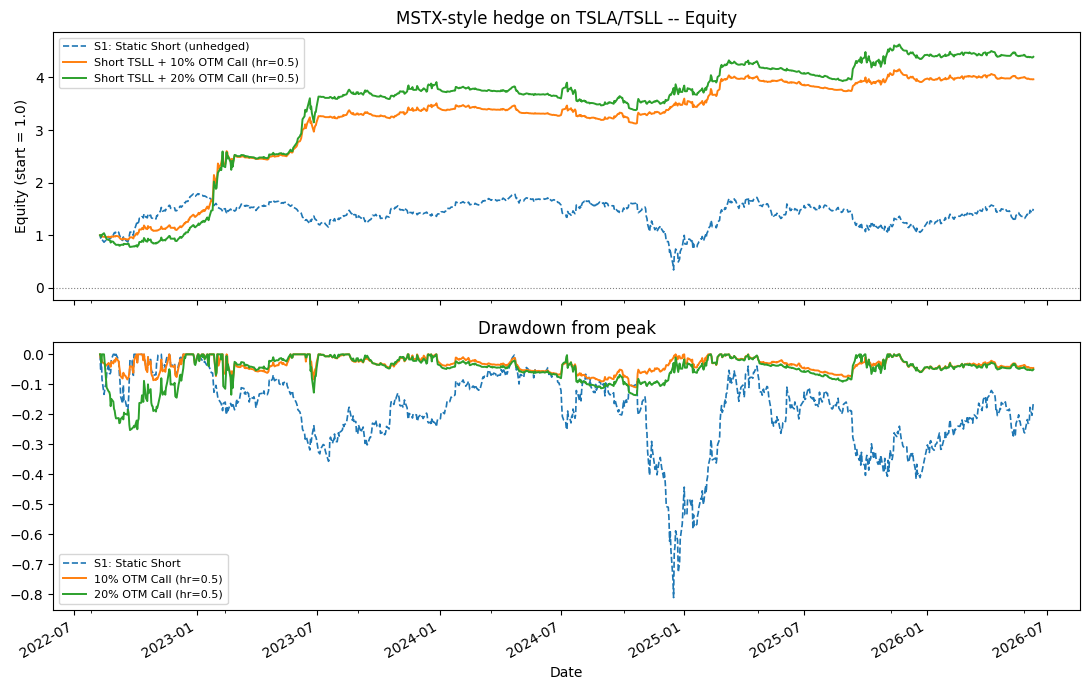

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

equity_static_short.plot(ax=axes[0], label="S1: Static Short (unhedged)", linewidth=1.2, linestyle="--")
for bucket, (eq, _) in results.items():
    eq.plot(ax=axes[0], label=f"Short TSLL + {bucket} Call (hr=0.5)", linewidth=1.4)
axes[0].axhline(0, color="grey", linestyle=":", linewidth=0.8)
axes[0].set_title("MSTX-style hedge on TSLA/TSLL -- Equity")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=8)

dd_static = equity_static_short / equity_static_short.cummax() - 1
dd_static.plot(ax=axes[1], label="S1: Static Short", linewidth=1.2, linestyle="--")
for bucket, (eq, _) in results.items():
    dd = eq / eq.cummax() - 1
    dd.plot(ax=axes[1], label=f"{bucket} Call (hr=0.5)", linewidth=1.4)
axes[1].set_title("Drawdown from peak")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## Exact MSTX deck replication -- S1 / S2 / S3 delta-exposed / S3 delta-countered

Same four strategies, same parameter names, same legend labels as the teammates' MSTX
slide -- applied to TSLA/TSLL, zero changes to the methodology:

- **S1**: unhedged short (wipes out on rally)
- **S2**: Short + TSLA call (m=1.1, h=0.5) -- partial hedge, calendar roll only
- **S3 delta-exposed**: Short + TSLA call (m=1.1, hr=1.0) -- full delta-neutral AT
  ENTRY, but not actively corrected between rolls (exposed to the same coverage-decay
  problem explored earlier this session)
- **S3 delta-countered**: Short + TSLA call (m=1.1, hr=1.5, re-strike 10%) -- over-hedged
  and actively re-struck whenever TSLA moves 10% from where the held contract was struck,
  not just on the calendar

In [8]:
MONEYNESS_M = "10% OTM"  # m=1.1

eq_s1 = equity_static_short  # already computed above

eq_s2, s2_rolls, hr_s2 = simulate_mstx_style(MONEYNESS_M, hedge_ratio=0.5)
eq_s3_exposed, s3e_rolls, hr_s3e = simulate_mstx_style(MONEYNESS_M, hedge_ratio=1.0)
eq_s3_countered, s3c_rolls, hr_s3c = simulate_mstx_style(MONEYNESS_M, hedge_ratio=1.5)

print(f"S2 (h=0.5): {s2_rolls} rolls")
print(f"S3 delta-exposed (hr=1.0): {s3e_rolls} rolls")
print(f"S3 delta-countered (hr=1.5): {s3c_rolls} rolls")


S2 (h=0.5): 23 rolls
S3 delta-exposed (hr=1.0): 23 rolls
S3 delta-countered (hr=1.5): 23 rolls


## Risk metrics -- all four, same table shape as the MSTX deck

In [9]:
rows = [
    summarize(eq_s1, eq_s1.pct_change().dropna(), "S1 unhedged short"),
    summarize(eq_s2, eq_s2.pct_change().dropna(), "S2 Short + TSLA call (m=1.1, h=0.5)"),
    summarize(eq_s3_exposed, eq_s3_exposed.pct_change().dropna(), "S3 delta-exposed (m=1.1, hr=1.0)"),
    summarize(eq_s3_countered, eq_s3_countered.pct_change().dropna(), "S3 delta-countered (m=1.1, hr=1.5)"),
]
metrics_df_4 = pd.DataFrame(rows)
metrics_df_4


,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,S1 unhedged short,0.111697,0.709085,0.471940,-0.810748,0.137770
1,"S2 Short + TSLA call (m=1.1, h=0.5)",0.431998,0.220334,1.745915,-0.115942,3.725975
2,"S3 delta-exposed (m=1.1, hr=1.0)",0.624272,0.390537,1.431785,-0.316185,1.974386
3,"S3 delta-countered (m=1.1, hr=1.5)",0.767628,0.610319,1.214280,-0.687122,1.117164


## Plot -- exact same legend labels/structure as the MSTX deck

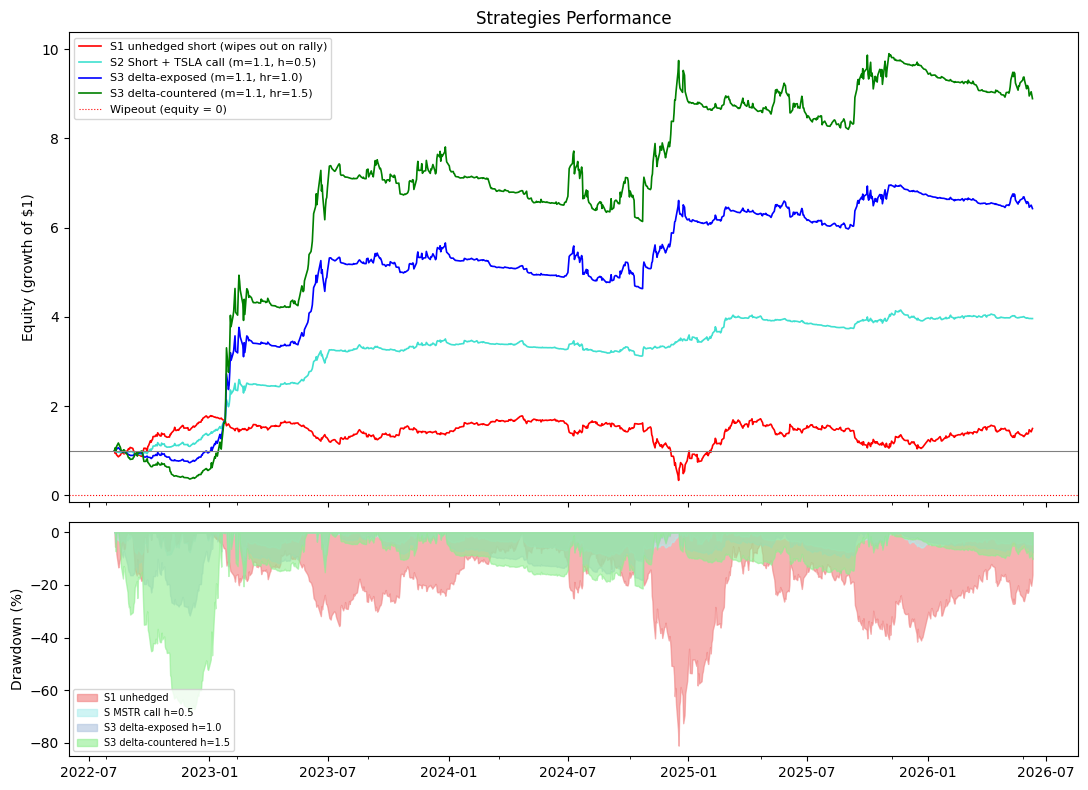

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

eq_s1.plot(ax=axes[0], color="red", linewidth=1.2, label="S1 unhedged short (wipes out on rally)")
eq_s2.plot(ax=axes[0], color="turquoise", linewidth=1.2, label="S2 Short + TSLA call (m=1.1, h=0.5)")
eq_s3_exposed.plot(ax=axes[0], color="blue", linewidth=1.2, label="S3 delta-exposed (m=1.1, hr=1.0)")
eq_s3_countered.plot(ax=axes[0], color="green", linewidth=1.2, label="S3 delta-countered (m=1.1, hr=1.5)")
axes[0].axhline(1.0, color="grey", linewidth=0.8)
axes[0].axhline(0.0, color="red", linestyle=":", linewidth=0.8, label="Wipeout (equity = 0)")
axes[0].set_title("Strategies Performance")
axes[0].set_ylabel("Equity (growth of $1)")
axes[0].legend(fontsize=8, loc="upper left")

for eq, label, color in [(eq_s1, "S1 unhedged", "lightcoral"),
                         (eq_s2, "S MSTR call h=0.5", "paleturquoise"),
                         (eq_s3_exposed, "S3 delta-exposed h=1.0", "lightsteelblue"),
                         (eq_s3_countered, "S3 delta-countered h=1.5", "lightgreen")]:
    dd = (eq / eq.cummax() - 1) * 100
    axes[1].fill_between(dd.index, dd.values, 0, color=color, alpha=0.6, label=label)
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend(fontsize=7, loc="lower left")

fig.tight_layout()
plt.show()


## Realized hedge ratio over time -- drift from each strategy's base

Each series equals its nominal `hedge_ratio` (0.5 / 1.0 / 1.5) exactly at the moment a
contract is struck, then drifts as TSLA's delta changes with spot/vol/time until the next
calendar roll resets it. This is the coverage-drift mechanism from earlier in the session,
now shown directly for these three static, non-reactive hedges -- no daily correction,
just watch how far it wanders between rolls.

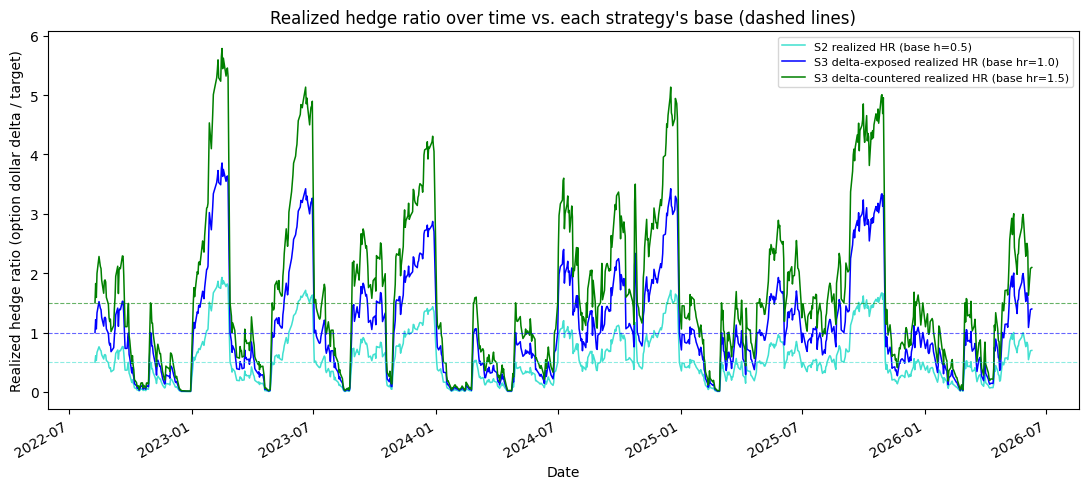

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))

hr_s2.plot(ax=ax, label="S2 realized HR (base h=0.5)", linewidth=1.1, color="turquoise")
hr_s3e.plot(ax=ax, label="S3 delta-exposed realized HR (base hr=1.0)", linewidth=1.1, color="blue")
hr_s3c.plot(ax=ax, label="S3 delta-countered realized HR (base hr=1.5)", linewidth=1.1, color="green")

ax.axhline(0.5, color="turquoise", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(1.0, color="blue", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(1.5, color="green", linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title("Realized hedge ratio over time vs. each strategy's base (dashed lines)")
ax.set_ylabel("Realized hedge ratio (option dollar delta / target)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
